

# Predicting Property Prices in Mexico Using Machine Learning | Cyann Williams

The goal of this project is to predict property prices in Mexico using machine learning techniques. Real estate pricing is influenced by multiple factors such as location, property size, and property type, making it a suitable problem for regression modeling.

The dataset used in this project contains real estate listings from Mexico and includes features such as property type, state, latitude, longitude, area in square meters, and price in U.S. dollars. Using these features, I will build a regression model that can learn patterns and accurately predict property prices. A Decision Tree Regressor is used as the primary model, and its performance is evaluated using RMSE and R².

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

In [40]:
from sklearn.tree import plot_tree

# Wrangle Function #
Removing duplicates, handling missing values, and filtering extreme outliers.

In [4]:
def wrangle(filepath):

    df = pd.read_csv(filepath)

    # Remove duplicates
    df = df.drop_duplicates()

    # Remove columns with more than 50% missing values
    missing_pct = df.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > 0.5].index
    df = df.drop(columns=cols_to_drop)

    # Remove extreme outliers in price
    low, high = df["price_usd"].quantile([0.01, 0.99])

    df = df[df["price_usd"].between(low, high)]

    return df

In [13]:
#LOADING DATA
df = wrangle("/Users/Conns/Downloads/mexico-real-estate-clean.csv")

# Data Inspection
Checking data types, summary statistics, and sample rows

In [14]:
df.head()

,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 1698 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  1698 non-null   str    
 1   state          1698 non-null   str    
 2   lat            1698 non-null   float64
 3   lon            1698 non-null   float64
 4   area_m2        1698 non-null   float64
 5   price_usd      1698 non-null   float64
dtypes: float64(4), str(2)
memory usage: 92.9 KB


In [16]:
df.describe()

,lat,lon,area_m2,price_usd
count,1698.000000,1698.000000,1698.000000,1698.000000
mean,20.763089,-98.755012,170.345701,113858.907845
std,2.722675,4.878053,80.102822,62330.097569
min,15.752900,-117.054763,60.000000,34246.210000
25%,19.272088,-100.393310,102.000000,65789.470000
50%,19.637257,-99.202368,157.000000,98721.790000
75%,21.075163,-98.234951,220.000000,150000.000000
max,32.665619,-86.767539,385.000000,305263.160000


# EDA
Visualization to show the distribution of property prices to understand how values are spread and to identify skewness.

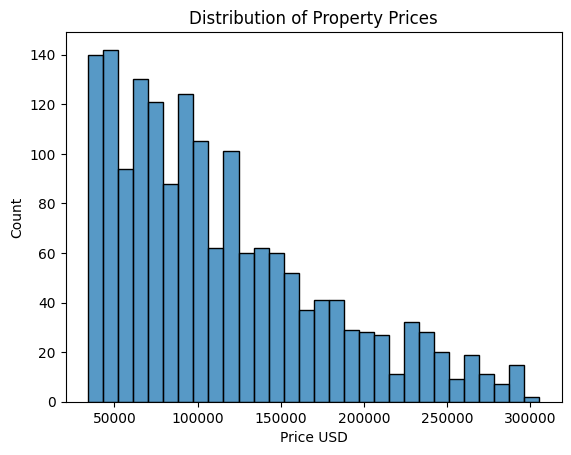

In [17]:
#PRICE DISTRIBUTION
sns.histplot(df["price_usd"], bins=30)

plt.title("Distribution of Property Prices")
plt.xlabel("Price USD")

plt.show()

This dataset is skewed to the right.

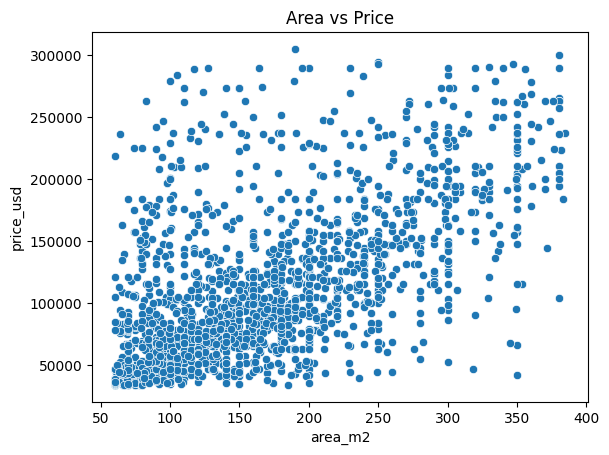

In [19]:
#AREA vs. PRICE
sns.scatterplot(
    data=df,
    x="area_m2",
    y="price_usd"
)

plt.title("Area vs Price")

plt.show()

In general, there is a positive correlaiton between the area_m2 and the price_usd. This suggests that the more area a home has, the more it will cost.

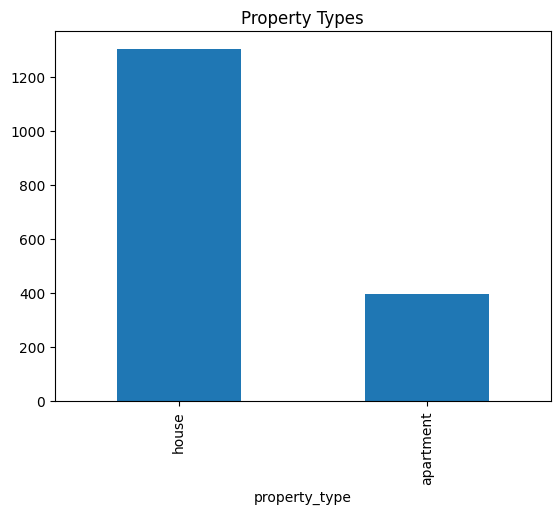

In [20]:
#PROPERTY TYPE COUNTS (HOUSE vs. APT)

df["property_type"].value_counts().plot(kind="bar")

plt.title("Property Types")

plt.show()

In this data set, there are more houses than apartments. I separated houses and apartments because they follow different pricing structures. Houses are typically influenced by land size and total area, while apartments are more dependent on location and shared building features. Combining them could introduce noise and distort the relationship between features and price. By separating them, the model can learn more consistent patterns and produce more accurate predictions.

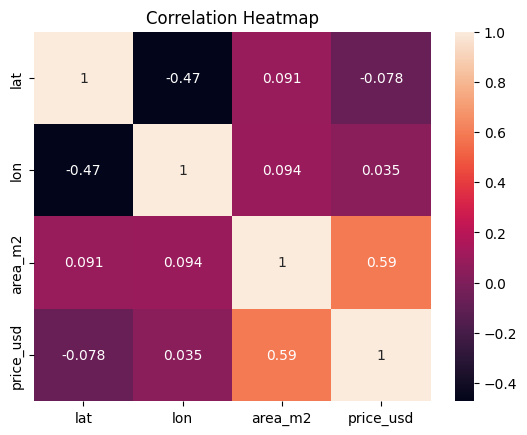

In [21]:
#CORRELATION HEATMAP

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

Strongest Positive Correlation (0.59) is found between area_m2 and price_usd. Larger properties moderately correlate with higher prices.


# Feature Selection #

In [24]:
features = [
    "area_m2",
    "lat",
    "lon"
]
df = pd.get_dummies(
    df,
    columns=["property_type", "state"],
    drop_first=True
)

# Split Data

In [26]:
X = df.drop(columns="price_usd")

y = df["price_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Baseline Model #

In [29]:
import numpy as np
from sklearn.metrics import mean_squared_error

baseline_pred = y_train.mean()

baseline_preds = [baseline_pred] * len(y_train)

baseline_mse = mean_squared_error(y_train, baseline_preds)
baseline_rmse = np.sqrt(baseline_mse)

print(baseline_rmse)

63025.16430480398


If we always predicted the average house price, we’d be off by about $63,000 USD on average.

# Decison Tree Model #

A Decision Tree Regressor was chosen because it is a simple yet powerful machine learning model that can capture nonlinear relationships between features and property prices. Real estate data is often complex, with interactions between variables such as location, area, and property type, and decision trees are well-suited for handling these types of patterns without requiring strong assumptions about the data.

In [33]:
model = make_pipeline(
    SimpleImputer(),
    DecisionTreeRegressor(
        max_depth=6,
        random_state=42
    )
)

In [34]:
#train data
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite

# Prediction

In [35]:
y_pred = model.predict(X_test)

The model predictions represent the estimated property prices generated by the Decision Tree Regressor for the test dataset. Each predicted value corresponds to a property in X_test and is based on the patterns learned during training. These predictions are compared to the actual prices (y_test) to evaluate model performance.

# Evaluation

In [37]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 43434.55418801193
R²: 0.4648955770499522


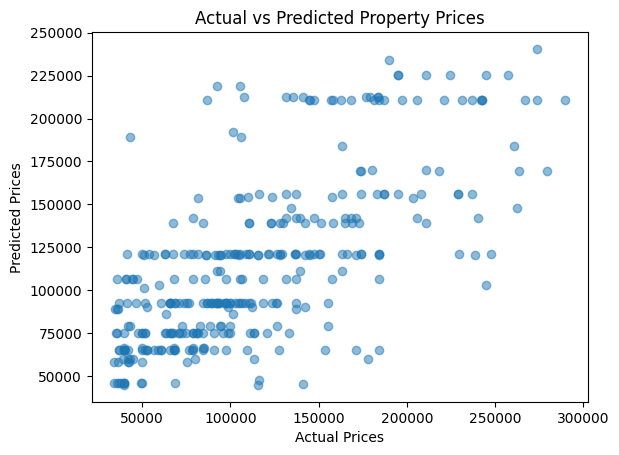

In [42]:

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Property Prices")

plt.show()

# Feature Importance

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


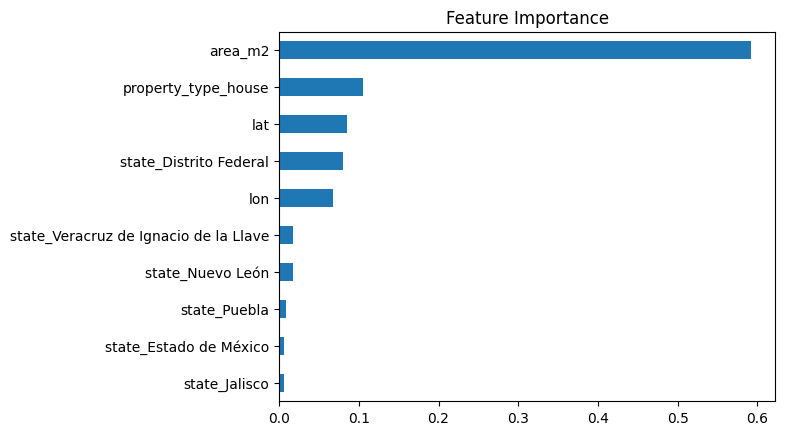

In [39]:
tree = model.named_steps["decisiontreeregressor"]

importance = pd.Series(
    tree.feature_importances_,
    index=X_train.columns
)

importance.sort_values().tail(10).plot(kind="barh")

plt.title("Feature Importance")

plt.show()

# Conclusion


The goal of this project was to predict property prices in Mexico using machine learning based on features such as area, location, and property characteristics. A Decision Tree Regressor was used as the final model.

After data cleaning and exploratory data analysis, the dataset was split into training and testing sets. A baseline model using the mean price resulted in a high error, with an RMSE of approximately $63,025.

The Decision Tree Regressor improved performance, achieving an RMSE of approximately $43,435 on the test set. This demonstrates that the model is able to capture meaningful relationships between the input features and property prices.mThe model achieved an R² score of 0.465, meaning it explains about 46.5% of the variance in housing prices. While this indicates moderate predictive power, it is expected due to the complexity of real estate pricing, which is influenced by additional factors not included in the dataset such as neighborhood quality, economic conditions, and property condition.

Overall, the model performed better than the baseline and provides reasonable predictive ability. Future improvements could include using more advanced models such as Random Forest or Gradient Boosting, incorporating additional location-based features, and performing hyperparameter tuning to improve accuracy.